# Matrix Multiplication from foundation
_Note: This notebook is based on original 'Matrix Multiplication from foundation' notebook named '01_matmul.ipynb' of fastai course named 'practical deep learning for coders part2'._

## Import
First we create the path with parent directory named `mnist_data`.Then we make directory named `mnist_data` using the method `mkdir` of the `pathlib`.
- `mkdir(parent=bool,exist_ok=bull)`: By default parents and exist_ok parameter are set to be false. We set parent as true if we have any directory missing in our path so that it will create those directory before making the final directory but if it's false then missing parent directories will raise error.

`exist_ok`: By default, it is false and it will raise error if the target directory already exists. If it's true then python won't raise error and existing target directory is left as it is.

What is mnist.pkl.gz?
It is a highly compressed version of a Python object.

`.pkl (Pickle)`: This is a Python-specific file format used to "freeze" or serialize objects (like lists, dictionaries, or in this case, a large collection of handwritten digit images).

`.gz (Gzip)`: This is a compression format (similar to a .zip file). Because datasets can be quite large, they are often "gzipped" to make them faster to download over the internet.

In [66]:
from pathlib import Path
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz?raw=true'
path_data = Path('mnist_data')
path_data.mkdir(exist_ok=True)
path_gz = path_data/'mnist.pkl.gz'

## urlretrieve
`if not path_gz.exists()`: Python checks your folder. If the file is already there (perhaps from a previous time you ran the code), it skips the next part to save time.

`urlretrieve(MNIST_URL, path_gz)`: This is the "creation" moment. This function connects to the internet, goes to the MNIST_URL, downloads the data, and saves it to your computer using the name and location you stored in path_gz by creating file if necessary.


In [67]:
from urllib.request import urlretrieve
if not path_gz.exists():
    urlretrieve(MNIST_URL,path_gz) # download the things available in above url and store them in path_gz if not create and store

Running powershell command to test if the file exists.

In [68]:
!dir

mnist_data  sample_data


`with gzip.open(path_gz, 'rb') as f:`
This part handles opening the compressed file safely.

`with`: This is a "context manager." It ensures that the file is automatically closed as soon as the code inside the block finishes, even if an error occurs. This prevents memory leaks. With statement can be used for for file handling by replacing Try-Except finally with "with" statement as we don't have to manually care about closing the file and memory leak as it handles automatically.

`gzip.open`: Since the file ends in .gz, a regular open() won't work. This function decompresses the data "on the fly" as it reads it.

`'rb'`: This stands for Read Binary. And can also be used such as 'r' for read, 'w' for writing and many other.

`r`: Open for reading (you aren't changing the file).

`b`: Read as raw bytes rather than text. Since a Pickle file is a serialized object (not a simple text file like a .txt or .csv), Python needs to see the raw 1s and 0s.

`as f`: This gives the open file a temporary nickname, f, so you can refer to it in the next line.


`pickle.load(f, encoding='latin-1')`

Now that the "wrapper" (the gzip) is open, we need to translate the data inside.

`pickle.load(f)`: This takes the binary stream from f and reconstructs it back into Python objects (like NumPy arrays or lists).

`encoding='latin-1'`: This is a bit of "legacy" insurance. The original MNIST pickle file was likely created using Python 2. Python 3 handles text and data differently, so latin-1 tells Python 3 how to correctly decode the byte strings from that older format without crashing.


The data inside the MNIST file is structured as a tuple of tuples. Python allows you to "unpack" them into variables all at once:

- (x_train, y_train): The first part of the file contains the training images and their labels.

- (x_valid, y_valid): The second part contains the validation data (used to tune the model).

- _: The third part is the "test" data. The underscore _ is a Python convention that means: "I know there is data here, but I don't plan on using it, so just throw it away."

In [69]:
import pickle, gzip
with gzip.open(path_gz, 'rb') as f:
    ((x_train,y_train),(x_valid,y_valid),_) = pickle.load(f,encoding='latin-1')

## Image processing
Since our x_train contains 50000 image of 784px (28px*28px). Let's take our first image. It will contain 784 elements together since the elements aren't arranged in 28 rows and 28 column.

let's look 10 random elements from middle of the image by taking from 200 to 210.

- `x_train[0]`: This is the first image in your dataset. In MNIST, images are stored as a flat list of 784 numbers ($28 \times 28 = 784$).

- `vals = lst1[200:210]`: This just grabs a small "snippet" of 10 pixels from the middle of that list so you can see how the iterator works on a small scale.

In [70]:
img1_lst = list(x_train[0])
demo_val = img1_lst[200:210]
demo_val

[np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.19140625),
 np.float32(0.9296875),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125)]

What is iterator?

An iterator is like a "pointer" or a conveyor belt. When you call iter(vals), you aren't making a copy of the list; you are creating an object that remembers your current position. Every time you take an item out, the pointer moves forward and never goes back.

- `islice(it, 5)`: This says "Go to the iterator it and grab the next 5 items."

- The Magic of Iterators: Notice in your example that the first time you call it, you get the first 5 numbers. The second time you call it, you get the next 5 numbers. The iterator "remembers" it already gave away the first 5.

- `The Empty List []`: Once the "conveyor belt" is empty, islice returns nothing.

In [71]:
it = iter(demo_val)
from itertools import islice
list(islice(it,5))

[np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.19140625),
 np.float32(0.9296875)]

In [72]:
list(islice(it,5))

[np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125)]

In [73]:
list(islice(it,5))

[]

If you give iter() two arguments—a function and a sentinel value—it will keep running that function over and over until the function returns the sentinel value.
- **The Iterator (it)**: it = iter(img_lst) sets up our conveyor belt of all 784 pixels.
- **The "Chunker" (lambda: list(islice(it, 28)))**: This is a small function that says: "Grab the next 28 pixels from the conveyor belt and put them in a list."
- **The Sentinel ([])**: This tells iter() when to stop. "Keep grabbing chunks of 28 until islice runs out of pixels and returns an empty list []."
- **The Outer list():** This collects all those rows (chunks of 28) into one big list.

The Result: You transformed a flat list of 784 pixels into a list of 28 lists (each containing 28 pixels). This is a $28 \times 28$ grid.

What is the Output?

Yes, the output is a big list containing 28 smaller lists. Since the original MNIST images have 784 pixels, and $784 / 28 = 28$, you end up with a $28 \times 28$ grid (a list of 28 rows, where each row has 28 pixels).

Is iter() a Loop?

In this specific "two-argument" form, yes, iter() acts exactly like a loop.When you call iter(callable, sentinel), Python follows this internal logic:
- Run the lambda function.
- Does the result equal the sentinel (the [])?
- If no: Keep the result and go back to step 1.
- If yes: Stop immediately and don't return the sentinel.

In [74]:
it = iter(img1_lst)
img = list(iter(lambda:list(islice(it,28)),[]))
img

[[np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0)],
 [np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float3

`matplotlib` takes that grid of numbers and draws it. Because you organized the pixels into rows of 28, it finally looks like a handwritten digit (like a "5" or a "0") instead of just a random line of numbers.

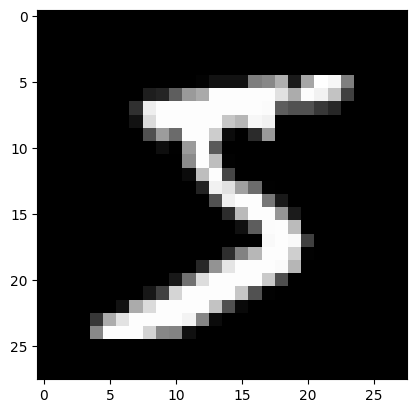

In [75]:
import matplotlib.pyplot as plt
plt.imshow(img)

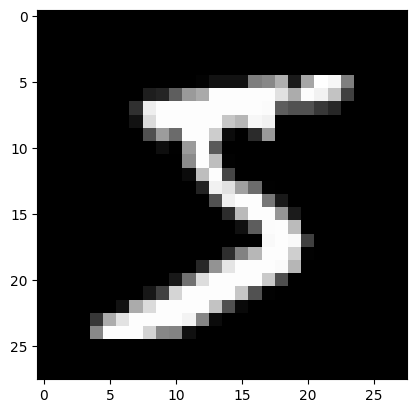

In [76]:
import matplotlib as mpl
mpl.rcParams['image.cmap'] = 'gray'
plt.imshow(img)

## Matrix and tensor:
Since our image is a big list of 28 small list and each 28 small list containing 28 elements. So, we can index out a particular element from a list of list using double of this operator `[]`.

Let's say, we want to see 20th list inside the big list and we want 15th item of that 20th list. Because those 28 small list are element for that big list we can write `img[20]` and to point out specific 15th element in that 20th list we can write combined `img[20][15]`.

In [77]:
img[20][15]

np.float32(0.98828125)

Although we can do it this way but a matrix has element representing a row and column usually in the form of $^aij$ where i represents the row and j represents the column.

Therefore, to make that arrangement we can form a class called `Matrix` which will always receive a list containing `[row,column]` and then we can search specific element in that big list by passing row and column in single operator `[]`.

`__getitem__`: In Python, `__getitem__` is a special (dunder) method that lets your objects support indexing and slicing using the square bracket syntax (`obj[key]`), just like lists, tuples, and dictionaries.

In [78]:
class Matrix:
    def __init__(self,mat):
        self.mat = mat
    def __getitem__(self,indices):# we will pass a list containing indices in the format [row,column]
        return self.mat[indices[0]][indices[1]]# we will return the particular element of that list where 1st index represent row and 2nd index represents column

In [79]:
m = Matrix(img)
m[20,15]

np.float32(0.98828125)

### Let's use pytorch
Since we were able to create our own matrix from scratch now, we are allowed to use the pytorch.

In [80]:
import torch
from torch import tensor

# let's make rank 1 tensor called vector
tensor([1,2,3])

tensor([1, 2, 3])

`map()`: map() function in Python applies a given function to each element of an iterable (list, tuple, set, etc.) and returns a map object (iterator). It is a higher-order function used for uniform element-wise transformations, enabling concise and efficient code.

Let's start with a simple example of using map() to convert a list of strings into a list of integers.
```python
s = ['1', '2', '3', '4']
res = map(int, s)
print(list(res))
```

In [81]:
x_train,y_train,x_valid,y_valid = map(tensor,(x_train,y_train,x_valid,y_valid))
x_train.shape

torch.Size([50000, 784])

Let's reshape our tensor. Our `x_train` tensor contains 50k images of size 784 px so each image is 28px * 28px.
To reshape we can write `x_train.reshape(-1,28,28)` because -1 means everything as it is or we can simply write 50000 if we wish then make 784 of 28 rows and 28 columns.

In [82]:
img = x_train.reshape((-1,28,28))
img.shape

torch.Size([50000, 28, 28])

Since our each image has 28 rows * 28 columns. Let's look into our first image.

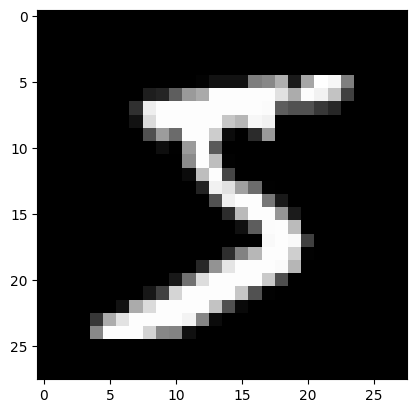

In [83]:
plt.imshow(img[0])

In [84]:
img[0,20,15]

tensor(0.9883)

Let's look into our result of training data. Since our validation set contains result of 50k images as a particular digit ranging from 0 to 9. Therefore, we have 50k digits in validation set so shape should be vector tensor of size `tensor.size[50000]`.

In [85]:
y_train,y_train.shape

(tensor([5, 0, 4,  ..., 8, 4, 8]), torch.Size([50000]))

`min()` and `max()` are python's built-in function and works in almost any collection like lists, tuples, etc. It is comparatively slower than `.min()` and `.max()` method of tensor. `.min()` and `.max()` is highly optimized and is more advanced so, prefer to use these.

In [86]:
min(y_train),max(y_train)

(tensor(0), tensor(9))

In [87]:
y_train.min(),y_train.max()

(tensor(0), tensor(9))

## Random Number

### Random number in python:
For everyday tasks (like picking a name from a list or generating a simple integer), you use the built-in random module.

In [88]:
import random

# A random float between 0.0 and 1.0
print(random.random())

# A random integer between 1 and 10 (includes both 1 and 10)
print(random.randint(1, 10))

# Pick a random element from a list
my_list = ['apple', 'banana', 'cherry']
print(random.choice(my_list))

0.6394267984578837
1
cherry


### Random Numbers in PyTorch
In PyTorch, you are usually creating Tensors (multi-dimensional arrays). These functions are highly optimized for speed and can run on your GPU.

In [89]:
# A tensor of shape (3, 3) with random floats between 0 and 1
# (Uniform distribution)
print(torch.rand(3, 3))

# A tensor of shape (3, 3) with "Normal" distribution
# (Mean of 0, variance of 1 — the classic bell curve)
print(torch.randn(3, 3))

# Random integers between a range (low=0, high=10) with a specific size
print(torch.randint(0, 10, (5,)))

tensor([[0.3696, 0.8956, 0.4543],
        [0.8566, 0.5243, 0.5519],
        [0.0777, 0.3272, 0.5251]])
tensor([[ 0.2489, -0.4692, -0.8826],
        [ 0.3590, -0.7614, -1.1209],
        [-0.3866, -1.1801,  0.8337]])
tensor([3, 7, 8, 3, 2])


### Setting a seed for consistency:
If you run the code above twice, you’ll get different numbers. In science and coding, we often need the same "random" numbers every time so we can debug our work. This is called setting a seed.

#### Setting seed in python

In [90]:
random.seed(42)

#### Setting seed in pytorch

In [91]:
torch.manual_seed(42)

## Matrix multiplication

In [92]:
x_valid.shape

torch.Size([10000, 784])

`torch.Size([1000,784])` mean, we have 10000 rows each with 784 columns.

In [93]:
weights = torch.randn(784,10)
bias = torch.zeros(10)

In [94]:
weights.shape

torch.Size([784, 10])

`torch.Size([784, 10])` means we created a tensor containing 784 rows and 10 columns of random number between -1 to 1.

In [95]:
bias

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [96]:
bias.shape

torch.Size([10])

This states we successfully created a tensor with 1 row and 10 columns with value 0.

In [97]:
m1 = x_valid[:5]
m2 = weights
m1.shape, m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

- `m1=x_valid[:5]` means we are taking first 5 images from x_valid set.
### Why `m1.shape =  torch.Size([5,784])`?
This is because we have stored first 5 images with each 784px i.e. there are 5 rows and 784 columns.

### Why `m2.shape = torch.Size([784,10])`?
This is because we have 784px for each image and 10 actual digit as result. Since to determine result the computer has to look at each 784px so we have 784 weight for each 10 outcomes.

_Note: Since, matrix multiplication requires column of first row to be equal to the row of second matrix for successful matrix multiplication._

### Preparation for matrix multiplication:
Rule of matrix multiplication is simple:
- Column of first matrix should be equal to be rows of second matrix
- Shape of resulted matrix will be of size row of first matrix and column of second matrix. For example matrix A of size (2 X 3) and B of size (3 X 2) = C of size (2 X 2).

### Rules for writing a matrix multiplication in code:
- first loop will run equal to the number of rows of first matrix. Because resulting matrix will need that particular number of rows.
- second loop will run equal to the number of column of second matrix. Because each row consist of numbers of column equal to number of column of second matrix.
- third loop will run equal to the number of column of first matrix. Because column of first matrix and row of second matrix will multiply and add to become each element in the matrix.

For example:
$$
\begin{bmatrix}a&b\\c&d\end{bmatrix} * \begin{bmatrix}e\\f\end{bmatrix} = \begin{bmatrix}a*e+b*f\\c*e+d*f\end{bmatrix}
$$

In [98]:
first_row, first_column = m1.shape
second_row, second_column = m2.shape
(first_row,first_column),(second_row,second_column)

((5, 784), (784, 10))

We are destructuring the shape of first and second matrix into individual variable so that we can run the loop according to it.

In [99]:
result_matrix = torch.zeros(first_row,second_column)
result_matrix.shape

torch.Size([5, 10])

We are creating our resulting matrix of size of row of first matrix X column of second matrix and then initializing with tensor.zeros so that later we can store store actual value.

In [100]:
for i in range(first_row):
    for j in range(second_column):
        for k in range(first_column):
            result_matrix[i,j] += m1[i,k] * m2[k,j]

We wrote the loop for matrix multiplication but why this way?

- First loop: Since our resulting matrix will be of the size = number of row of first matrix X number of column of second matrix. Therefore, first loop will construct the all the row for the matrix.
- Second loop: In matrix multiplication, calculation happens through each row so second loop will fill all the column for each row.
- Third loop: In matrix multiplication, each of column of first matrix multiplies and adds each rows of second matrix to form one element. Therefore to make each element in each row we are perform number of calculation equal to first matrix column.

Inside third loop, what are we doing exactly:
- We are multiplying element at a matching column of first matrix with element at a matching row of second matrix and then add after each multiplication.
- Therefore to make one element for a resulting matrix, the number of loop is repeating to the equal number of element in a column of first matrix.

In [101]:
result_matrix

tensor([[ -5.2800,  10.2489,   2.0652,   4.3130,  -7.9081, -10.0272,   4.1046,
           1.8719,   2.9511,   8.2341],
        [  3.7020,  11.1935,   4.8821,  -2.8327, -12.3421,  -4.9976,  -4.0287,
          -0.1194,   2.4757,   6.8442],
        [ -0.6531,   0.9631,  13.6106,   0.6073,  -3.7691,  -7.9343,   5.2942,
           8.8896,   3.5046,   5.3019],
        [-18.8394,  10.8296,   0.3210, -10.0086,   1.6325,  -4.5385,  -0.0411,
          -2.0708,   9.8382,   8.8182],
        [ -8.4099,   4.8737,   0.9507,  13.3468, -13.5510,  -2.5057,   8.6968,
          -4.1114,   1.3863,  -2.5484]])

Looking over resulting matrix and it's shape.

In [102]:
result_matrix.shape

torch.Size([5, 10])

### Let's rewrite a clean matrix multiplication function:

In [103]:
def matmul(mat1,mat2):
    ar,ac = mat1.shape
    br,bc = mat2.shape
    mat3 = torch.zeros(ar,bc)
    for i in range(ar):
        for j in range(bc):
            for k in range(ac):
                mat3[i,j] += mat1[i,k] * mat2[k,j]
    return mat3

In [104]:
%time _ = matmul(m1,m2)

CPU times: user 756 ms, sys: 106 µs, total: 756 ms
Wall time: 759 ms


Let's look into time taken by our matrix multiplication function `matmul` to complete which is very slow but no worries because we will learn more faster approach of doing matrix multiplication soon.

## Numba

Numba is a python library designed to increase the execution of python code with the same speed like C++. Therefore, we can run slow python for mathematical computation very fast using Numba's `@njit`(Just-In-Time compiler) decorator.

_Note: Numba can run only NumPy and standard python math. It doesn't support Pytorch Tensors._

In [105]:
from numba import njit

import numpy as np
mat1 = m1.numpy()
mat2 = m2.numpy()
@njit
def n_matmul(mat1,mat2):
    ar,ac = mat1.shape
    br,bc = mat2.shape
    mat3 = np.zeros((ar,bc))
    for i in range(ar):
        for j in range(bc):
            for k in range(ac):
                mat3[i,j] += mat1[i,k] * mat2[k,j]
    return mat3

%time _ = n_matmul(mat1,mat2)

CPU times: user 221 ms, sys: 0 ns, total: 221 ms
Wall time: 227 ms


If we compare the execution speed time of python function and same function using numba, the execution speed of Numba's decorator function is faster.

## Broadcasting
The term broadcasting describes how numpy treats arrays with
different shapes during arithmetic operations. Subject to certain
constraints, the smaller array is “broadcast” across the larger
array so that they have compatible shapes. Broadcasting provides a
means of vectorizing array operations so that looping occurs in C
instead of Python. It does this without making needless copies of
data and usually leads to efficient algorithm implementations.

In simple terms, broadcasting is simply making non-similar shape or matrix of same shape for calculation without actually changing the original shape in reality.

### Broadcasting with a scalar

In [106]:
a = torch.tensor([10.,6.,-4.])
a

tensor([10.,  6., -4.])

In [107]:
a > 0

tensor([ True,  True, False])

How are we able to do a > 0? 0 is being broadcast to have the same dimensions as a.

It is because although 0 is single digit broadcasting is making 0 same as shape of `a`. Therefore, for calculation 0 is broadcasted as `tensor([10.,6.,-4.]) > tensor([0.,0.,0.])`.

For example, we can see other examples:

In [108]:
a + 1

tensor([11.,  7., -3.])

In [109]:
mat = torch.tensor([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])
mat

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [110]:
2*mat

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.],
        [14., 16., 18.]])

### Broadcasting a vector

In human language, what is broadcasting?

Answer: Broadcasting is essentially a way to perform math between tensors of different sizes without you having to manually write loops or copy data to make the sizes match.

Think of it as "Automatic Stretching." If you try to add a small thing to a big thing, PyTorch "stretches" the small thing until it’s the same size as the big thing.

In [111]:
c = tensor([10.,20.,30.]);c

tensor([10., 20., 30.])

In [112]:
mat.shape,c.shape

(torch.Size([3, 3]), torch.Size([3]))

As we can see, the size of mat is 3 X 3 matrix and c is vector but we can still perform mathematical operation because broadcasting will make it possible.

Let's say, we are doing `mat + c` then this will broadcast `c` to match the size of mat by making `c` also a 3 X 3 matrix like this:
$\begin{bmatrix}10.&20.&30.\\10.&20.&30.\\10.&20.&30.\end{bmatrix}$

In [113]:
mat + c

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

In order to see how c is being compatible, we can use `.expand_as()` method.

In [114]:
t = c.expand_as(mat)
t

tensor([[10., 20., 30.],
        [10., 20., 30.],
        [10., 20., 30.]])

In [115]:
t.stride(),t.shape

((0, 1), torch.Size([3, 3]))

We can see when we run `.stride()` method. It shows that it isn't a 3 X 3 matrix, it only has 3 columns but when we do `.shape()`, it shows it as 3 X 3. In actual sense, it is simply broadcasting to match the shape to perform calculation.

_Note: In actual, instead of actually creating a new matrix and filling it with 10s, 20s, and 30s (which wastes RAM), PyTorch just tells the computer: "Whenever you move to the next row, don't move forward in memory (Stride 0). Just reuse the same row you just used." It creates the illusion of a bigger matrix. This is a genius memory trick._

In [116]:
t.storage()

 10.0
 20.0
 30.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 3]

#### Rules of Broadcasting:
Let's understand the rules of broadcasting. In broadcasting, pytorch compares the dimensions of matrices from right side (trailing dimensions). The condition that says if they are compatible:
1. The size numbers are equal among matrices
```plaintext
    256*256*3
           *3
    ----------
    256*256*3
```
2. One of the size numbers is 1.
```plaintext
    256*256*1
          1*3
    ---------
    256*256*3
```

But before this, let's understand how to make a matrix compatible by fixing size using either `None` or `unsqueeze()`.

#### `squeeze()` and `unsqueeze()`
__Things to be Noted__
In NumPy and PyTorch, the term axis refers to a specific dimension of a multi-dimensional array (or tensor).
It determines which direction an operation is applied along.

__Understanding Axes__

- Axis 0 → The first dimension (rows in a 2D array).
- Axis 1 → The second dimension (columns in a 2D array).
- Axis 2, 3, ... → Higher dimensions in 3D, 4D, etc.
Think of axis as the index of the dimension you want to operate along.
- axis=0 / dim=0 → Operate down columns.
- axis=1 / dim=1 → Operate across rows.
_Note: In PyTorch, the parameter is called dim instead of axis, but it works the same way._

__`unsqueeze() - Add a dimension__

This function inserts a new dimension of size 1 at a specific position. It’s like taking a 1D list and putting it inside another set of brackets to make it a 2D matrix.
- __Why use it?__ You usually do this to make two tensors "compatible" for broadcasting or to prepare data for a neural network layer that expects a batch (e.g., changing a single image into a "batch of 1").

In [117]:
print(c)
c.unsqueeze(0)

tensor([10., 20., 30.])


tensor([[10., 20., 30.]])

So we can observe that the original tensor c was of shape of [3] because it was a vector. But when we use `.unsqqeeze(0)`, we are saying we want a row with 3 columns. Therefore, it stretches the [3] into [1,3]. In simple language, it means we are adding a fake dimension.

In [118]:
print(c); c[None,:]

tensor([10., 20., 30.])


tensor([[10., 20., 30.]])

The alternative of using `.unsqueeze(0)` is `[None,:]`, it does the same thing.

Let's look into the `.unsqueeze(1)`. This will simply add columns instead of row by adding fake dimension around each tensors turning tensor `c` of shape [3] into [3,1].

Similarly. [:,None] does same thing as `unsqueeze(1)`.

In [119]:
print(c.unsqueeze(1)); c[:,None]

tensor([[10.],
        [20.],
        [30.]])


tensor([[10.],
        [20.],
        [30.]])

__`squeeze()` - Remove a dimension__

Let's look into it, if `.unsqueeze(dim)` adds dimension in the particular mentioned dimension then `.squeeze(dim)` removes dimension from that particular mentioned dimension.

This function inserts a new dimension of size 1 at a specific position. It’s like taking a 1D list and putting it inside another set of brackets to make it a 2D matrix.

- __Why use it?__ You usually do this to make two tensors "compatible" for broadcasting or to prepare data for a neural network layer that expects a batch (e.g., changing a single image into a "batch of 1").

In [120]:
o = c.unsqueeze(0); p = c[:,None]
print(f'o before squeeze: {o}'); print(f'p before squeeze: {p}')
print("let's use squeeze")
o = o.squeeze(0); p = p.squeeze(1)
print(f'o after squeeze: {o}'); print(f'p after squeeze: {p}')

o before squeeze: tensor([[10., 20., 30.]])
p before squeeze: tensor([[10.],
        [20.],
        [30.]])
let's use squeeze
o after squeeze: tensor([10., 20., 30.])
p after squeeze: tensor([10., 20., 30.])


_Note: If you call .squeeze() on a dimension that isn't size 1 (e.g., a shape of [3, 3]), nothing happens. It only removes dimensions that are "empty" (size 1)._

__Explanation of Broadcasting rule__

__The Rule__: Two dimensions are compatible if they are equal in shape, or if one of them is 1.

Let's check with examples:
- Example 1: 3 x 3 and 3:
```plaintext
Tensor A: 3 x 3
Tensor B:     3  (Align to the right)
          -----
          3 x 3  (Success! The 3s match, and the missing dimension is treated as a 1)
```
- Right-most dimension: A is 3, B is 3 both matches so no problem.
- Next dimension: A is 3, B is nothing but pytorch will suppose it as 1. Since B is 1, it stretches to 3.
- Final Shape: 3x3.
---
- Example 2: 245 x 245 x 1 and 1
```plaintext
Tensor A: 245 x 245 x 1
Tensor B:             1
          -------------
          245 x 245 x 1 (Success! The 1s match)
```
- Right-most dimension: A is 1, B is 1 both matches so no problem.
- Next dimension: A is 245, B is nothing but pytorch will suppose it as 1. Since B is 1, it stretches (broadcast) to 245 to match the shape.
- Next dimension: A is 245, B is nothing but pytorch will suppose it as 1. Since B is 1, it stretches (broadcast) to 245 to match the shape.
- Final Shape: 245x245x1.
---
- Example 3: 3 x 3 and 2 (Fails)
```plaintext
Tensor A: 3 x 3
Tensor B:     2  (Align to the right)
          -----
          ERROR!  (3 and 2 are not equal, and neither is 1)
```
- Right-most dimension: A is 3, B is 2. Neither is 1, and they aren't equal so broadcasting isn't possible.
---
- Example 4: 3 x 1 and 1 x 2
```plaintext
Tensor A: 3 x 1
Tensor B: 1 x 2  (Align to the right)
          -----
          3 x 2  (Success)
```
- Right side: B has 2, A has 1. The 1 stretches to 2.
- Left side: A has 3, B has 1. The 1 stretches to 3.
- Result: You get a 3x2 matrix. This is the "Cross" broadcast where both tensors stretch in different directions!
---
- Example 5: 3 x 1 and 2 x 1
```plaintext
Tensor A: 3 x 1
Tensor B: 2 x 1  (Align to the right)
          -----
          ERROR!
```
- Right side: Both are 1. They match perfectly (1 and 1).
- Left side: A has 3, B has 2. Neither is 1 and they aren't equal. The "stretchiness" isn't there, so they crash.
---
- Example 6: 3 x 1 and 3 x 2
```plaintext
Tensor A: 3 x 1
Tensor B: 3 x 2  (Align to the right)
          -----
          3 x 2
```
- Right side: B has 2, A has 1. The 1 stretches to 2.
- Left side: Both are 3. They match perfectly! (3 and 3).
- Result: A 3x2 matrix.

### Einstein summation
[Einstein summation](https://ajcr.net/Basic-guide-to-einsum/) (einsum) is a compact representation for combining products and sums in a general way. The key rules are:

- Repeating letters between input arrays means that values along those axes will be multiplied together.
- Omitting a letter from the output means that values along that axis will be summed.

_Note: Einstein summation doesn't follow the rule of matrix multiplication because it is not matrix multiplication but it can produce result for matrix multiplication using it's row and column combination._

Representation fo ijk:
1. First matrix
- i: represents the row of first matrix
- j: represents the column of first matrix
2. Second matrix
- j: represents the row of second matrix
- k: represents the column of second matrix
3. Resulting matrix
- i: represents the row
- k: represents the column



In [121]:
a = torch.tensor([[1,2],[3,4]])
b = torch.tensor([[2,2],[3,3]])
print(a)
print(b)

tensor([[1, 2],
        [3, 4]])
tensor([[2, 2],
        [3, 3]])


In [122]:
mr = torch.einsum('ij,jk->ik',a,b)
print(mr)
mr.shape

tensor([[ 8,  8],
        [18, 18]])


torch.Size([2, 2])

Final tensor mr is 2 x 2 which is $\begin{bmatrix}8&8\\18&18\end{bmatrix}$ which is produced by the `einsum` is indeed equal to the result of matrix multiplication rule row of first matrix multiplies column of second matrix but `einsum` does it different way.

In order to see how it does lets look below:

In [123]:
torch.einsum('ij,jk->ijk',a,b)

tensor([[[ 2,  2],
         [ 6,  6]],

        [[ 6,  6],
         [12, 12]]])

When we mention `'ijk'`, we are saying we don't want the addition of two resulting matrix instead we want everything without addition which results in two resulting matrix in a big matrix. To get the final output as matrix multiplication the sum between those two resulting matrix is necessary.

What is happening:
- First matrix X second matrix = Third matrix

Rule:
- Each element multiplies of first matrix to with all the element in respective row of second matrix without sum to form respective result matrix of big matrix. (each element goes row-wise means each element multiplies one whole row)

__Step-by-Step Mathematical Calculation__
Because the result is ijk, the output shape will be (2, 2, 2). Let’s calculate each "slice" of the 3D cube.

__When $i=0$ (First row of A: [1, 2])__
- $j=0, k=0$: A[0,0] \times B[0,0] = 1 \times 2 = 2
- $j=0, k=1$: A[0,0] \times B[0,1] = 1 \times 2 = 2
- $j=1, k=0$: A[0,1] \times B[1,0] = 2 \times 3 = 6
- $j=1, k=1$: A[0,1] \times B[1,1] = 2 \times 3 = 6

__When $i=1$ (Second row of A: [3, 4])__
- $j=0, k=0$: A[1,0] \times B[0,0] = 3 \times 2 = 6
- $j=0, k=1$: A[1,0] \times B[0,1] = 3 \times 2 = 6
- $j=1, k=0$: A[1,1] \times B[1,0] = 4 \times 3 = 12
- $j=1, k=1$: A[1,1] \times B[1,1] = 4 \times 3 = 12

3. __The Final Result Structure__

If you print the result in PyTorch, it looks like two $2 \times 2$ matrices stacked on top of each other:

__Slice $i=0$:__
$$\begin{bmatrix} 2 & 2 \\ 6 & 6 \end{bmatrix}$$

__Slice $i=1$:__
$$\begin{bmatrix} 6 & 6 \\ 12 & 12 \end{bmatrix}$$

__Let's re-write our matmul function:__

In [124]:
def ein_matmul(mat1,mat2):
    return torch.einsum('ij,jk->ik',mat1,mat2)

%time _ =ein_matmul(m1,m2)

CPU times: user 229 µs, sys: 24 µs, total: 253 µs
Wall time: 199 µs


We can observe that our time for matrix multiplication using einsum is the fastest till now.

### Matrix multiplication using pytorch
Pytorch, it self has it's own operator for matrix multiplications:
- torch.matmul() or @ operator -> matrix multiplication
- torch.mul() or * operator -> for element wise multiplication

In [125]:
def py_matmul(mat1,mat2):
    m1 = torch.tensor(mat1)
    m2 = torch.tensor(mat2)
    return torch.matmul(m1,m2)

%time _ =py_matmul(mat1,mat2)

CPU times: user 732 µs, sys: 0 ns, total: 732 µs
Wall time: 1.32 ms


We can see pytorch's own operator for matrix multiplication is fastest among all.

### Cuda
This is the fastest way to do anything in gpu.

In [126]:
from numba import cuda

if torch.cuda.is_available:
  print('GPU is available')
  device = torch.device('cuda')
else:
  print('GPU isn\'t available')
  device = torch.device('cpu')

m1 = m1.to(device)
m2 = m2.to(device)

r_mat = m1 @ m2
f_ans = r_mat.cpu()
print(f_ans)

GPU is available
tensor([[ -5.2800,  10.2489,   2.0652,   4.3130,  -7.9081, -10.0272,   4.1046,
           1.8719,   2.9511,   8.2341],
        [  3.7020,  11.1935,   4.8821,  -2.8327, -12.3421,  -4.9976,  -4.0287,
          -0.1194,   2.4757,   6.8442],
        [ -0.6531,   0.9631,  13.6106,   0.6073,  -3.7691,  -7.9343,   5.2942,
           8.8896,   3.5046,   5.3019],
        [-18.8394,  10.8296,   0.3210, -10.0086,   1.6325,  -4.5385,  -0.0411,
          -2.0708,   9.8383,   8.8182],
        [ -8.4099,   4.8737,   0.9507,  13.3468, -13.5510,  -2.5057,   8.6968,
          -4.1114,   1.3863,  -2.5484]])


We know the rule of matrix multiplication that A x B = C and the shape of C is the row of A and column of B. Therefore, our res_mat is at the shape of [5,10].

In [127]:
print(m1.shape)
print(m2.shape)
res_mat = np.zeros([5,10])
res_mat.shape

torch.Size([5, 784])
torch.Size([784, 10])


(5, 10)

__Understanding Grid, Block and Thread__

Imagine you have to paint a massive $1000 \times 1000$ floor.
- The Thread (The Worker): One person with a brush.
- The Block (The Team): A group of workers (e.g., $16 \times 16 = 256$ people) assigned to paint one specific square area.
- The Grid (The Entire Factory): The collection of all teams needed to cover the whole floor.

__What are those variables?__
- threads_per_block = (16, 16): You are telling the GPU: "I want my workers in teams of 256 ($16 \times 16$)."
- blocks_per_grid = (2, 2): You are telling the GPU: "I have a $32 \times 32$ floor. Since each team handles a $16 \times 16$ area, I need 4 teams ($2 \times 2$) to cover the whole thing."
- cuda.grid(2): This is the worker's GPS. When a worker starts, they ask, "Where am I on this huge floor?" cuda.grid(2) returns their exact (row, col) coordinates.

__In Simple way__
- Threads are number of worker we want to use. It is always better to use multiple of 32. Safe and common 256 (16 * 16) and maximum 1024 (32 * 32).
- Blocks are the team required in each grids to perform the task. So, a grid can accomodate 1 or 2 or 3 or more group of threads (workers) to do an assigned task in the grid.
- Grid is division of gpu into parts to do the job. For example, 1d matrix will have grid (1) containing 1 or 2 or 3 or more blocks with each block containing 64, 128, 256, 512, 1024, etc. numbers of thread to do the job, 2d matrix will have (2) grid, 3d matrix will have (3),etc.

In [128]:
import math
@cuda.jit
def cuda_matmul(mat1,mat2,result_matrix):
  row, col = cuda.grid(2)
  if row < result_matrix.shape[0] and col < result_matrix.shape[1]:
    temp = 0
    for k in range (mat1.shape[1]):
      temp += mat1[row,k] * mat2[k,col]
    result_matrix[row,col] = temp

dev_a = cuda.to_device(mat1)
dev_b = cuda.to_device(mat2)
dev_c = cuda.to_device(res_mat)

# setting up our kernel for gpu
threads_per_block = (16,16)
blocks_per_grid = (math.ceil(res_mat.shape[0]/threads_per_block[0]),math.ceil(res_mat.shape[1]/threads_per_block[1]))

cuda_matmul[threads_per_block,blocks_per_grid](dev_a,dev_b,dev_c) #[] represents the GPU function which are special
final_res = dev_c.copy_to_host()
print(final_res)


[[ -5.27997124  10.24891824   2.06515241   4.3129695   -7.90811408
  -10.02721803   4.10459223   1.87191626   2.95108326   8.23410538]
 [  3.70204218  11.19349878   4.88213302  -2.83265755 -12.34208165
   -4.99756703  -4.02871064  -0.11943546   2.47566055   6.84424397]
 [ -0.65314427   0.96312266  13.61060898   0.60727637  -3.76908996
   -7.93434187   5.29420128   8.8896031    3.50464762   5.30188799]
 [-18.83940628  10.82964261   0.32099766 -10.00860998   1.63245393
   -4.53851292  -0.04113878  -2.07075593   9.8382489    8.81816285]
 [ -8.40988205   4.8736543    0.95071817  13.34682773 -13.5509968
   -2.5057406    8.69679313  -4.11144361   1.38627878  -2.54842189]]


1. Why cuda.grid(2)?

The number in the parentheses refers to the number of dimensions in your grid.
- grid(1): Used for a simple 1D list (a Vector). The worker only gets one coordinate: i.
- grid(2): Used for a 2D surface (a Matrix). The worker gets two coordinates: (row, col).
- grid(3): Used for 3D volumes (like a video or a medical scan). The worker gets (x, y, z).

Since we are doing Matrix math, we have rows and columns. That's why we use 2.

2. Why 16 x 16 for Threads Per Block?

This number is a choice, but it’s guided by the Hardware's physical limits.
- __The Rule of 32:__ GPU hardware works in groups of 32 (called "Warps"). If you pick a multiple of 32 (like $16 \times 16 = 256$), the GPU runs efficiently.- __The Limit:__ Most modern GPUs (like NVIDIA's) allow a maximum of 1024 threads per block.
  -$16 \times 16 = 256$ (Safe and common)
  - $32 \times 32 = 1024$ (The absolute maximum
  - )$8 \times 8 = 64$ (A bit small, might be slow)

__Why 16x16?__

It’s a "sweet spot." It’s a multiple of 32, and it’s small enough that the GPU can manage many of these "teams" at once.

3. How do we know how many Blocks we need?

This is a math calculation based on your Data Size. You want to make sure your "Teams" (Blocks) cover the entire "Floor" (Matrix).

__The Formula:__
$$\text{Blocks} = \frac{\text{Total Data Size}}{\text{Threads Per Block}}$$

__Let's do the math for your $32 \times 32$ matrix:__
- You have 32 rows. Your team covers 16 rows.
  - $32 / 16 = \mathbf{2}$ Blocks for the rows.
- You have 32 columns. Your team covers 16 columns.
  - $32 / 16 = \mathbf{2}$ Blocks for the columns.

That is exactly where blocks_per_grid = (2, 2) comes from!

__What if the math isn't perfect?__

If you have a $33 \times 33$ matrix, $33/16 = 2.06$. You can't have half a block, so you Round Up (using math.ceil). You would use (3, 3) blocks and use an if statement in the code to tell the extra workers to stay idle.

4. __How many total workers do we have?__

To find the total number of "people" hired for the job, you multiply everything together:$$\text{Total Workers} = (\text{Blocks in X} \times \text{Blocks in Y}) \times (\text{Threads per Block})$$

__For our example:__
- $(2 \times 2) = \mathbf{4}$ Blocks (Teams)
- Each block has $16 \times 16 = \mathbf{256}$ Workers
- Total: $4 \times 256 = \mathbf{1024}$ total workers.

Since our matrix is $32 \times 32 = 1024$, every single pixel gets exactly one worker.

In [129]:
%time _ =cuda_matmul[threads_per_block,blocks_per_grid](dev_a,dev_b,dev_c)

CPU times: user 0 ns, sys: 1.06 ms, total: 1.06 ms
Wall time: 1.83 ms


It was supposed to be super fast than our previous speed but looks like I messed up.